# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [9]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [11]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [12]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

cv_df = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
display(cv_df.sort_values('rank_test_score').head(10))

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist, n_iter=50, cv=5, scoring='f1_macro',
    random_state=42, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [14]:
from sklearn.metrics import classification_report
from sklearn.base import clone

models_to_eval = {
    'SVM baseline': clone(base_models['SVM']),
    'SVM Grid Search': svm_grid_search.best_estimator_,
    'RF baseline': clone(base_models['RandomForest']),
    'RF Random Search': rf_random_search.best_estimator_,
}

summary = []
for name, model in models_to_eval.items():
    if name in ('SVM baseline', 'RF baseline'):
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    if name == 'SVM baseline':
        cv_mean, cv_std = baseline_results['SVM']
    elif name == 'SVM Grid Search':
        cv_mean = svm_grid_search.best_score_
        cv_std = svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]
    elif name == 'RF baseline':
        cv_mean, cv_std = baseline_results['RandomForest']
    else:
        cv_mean = rf_random_search.best_score_
        cv_std = rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]

    summary.append({'Модель': name, 'CV F1': f'{cv_mean:.4f}±{cv_std:.4f}', 'Test F1': f'{test_f1:.4f}'})
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred))

display(pd.DataFrame(summary))


=== SVM baseline ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== SVM Grid Search ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== RF baseline ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weight

,Модель,CV F1,Test F1
0,SVM baseline,0.9694±0.0193,0.9812
1,SVM Grid Search,0.9786±0.0176,0.9812
2,RF baseline,0.9504±0.0255,0.9526
3,RF Random Search,0.9554±0.0204,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

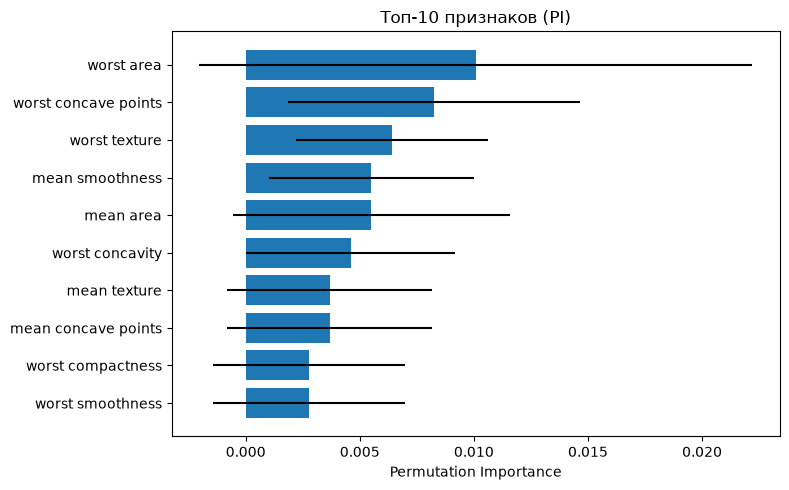

In [15]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

pi_result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro'
)

pi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pi_result.importances_mean,
    'std': pi_result.importances_std,
}).sort_values('importance', ascending=False)

top10 = pi_df.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10['feature'][::-1], top10['importance'][::-1], xerr=top10['std'][::-1])
plt.xlabel('Permutation Importance')
plt.title('Топ-10 признаков (PI)')
plt.tight_layout()
plt.show()

Топ-5 PI:  ['mean smoothness', 'worst concave points', 'mean area', 'worst texture', 'worst area']
Топ-5 FI:  ['mean concave points', 'worst concave points', 'worst radius', 'worst perimeter', 'worst area']
Совпадение топ-5: False


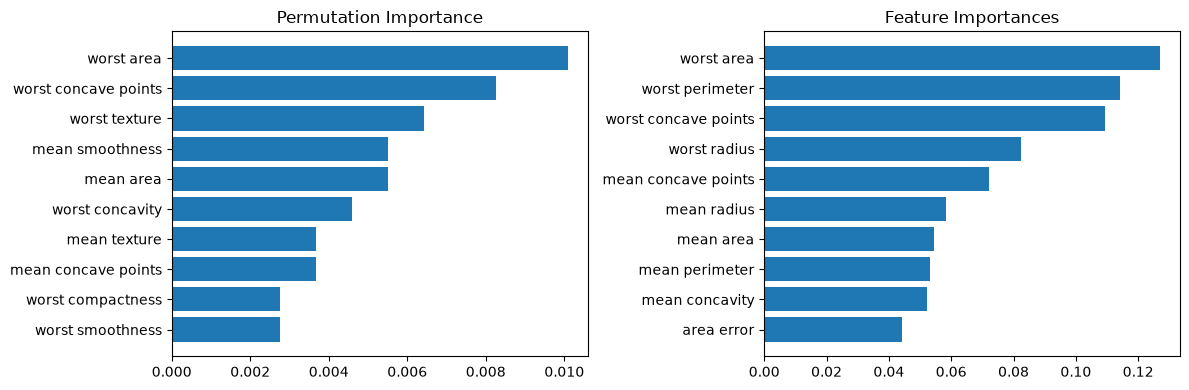

In [16]:
# Встроенная важность RF (для сравнения)

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_,
}).sort_values('importance', ascending=False)

top5_pi = set(pi_df.head(5)['feature'])
top5_fi = set(fi_df.head(5)['feature'])
print(f'Топ-5 PI:  {list(top5_pi)}')
print(f'Топ-5 FI:  {list(top5_fi)}')
print(f'Совпадение топ-5: {top5_pi == top5_fi}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [pi_df, fi_df], ['Permutation Importance', 'Feature Importances']):
    top = df.head(10)
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_title(title)
plt.tight_layout()
plt.show()

# PI учитывает взаимодействия признаков, FI — разбиения в деревьях.
# Расхождения возможны при коррелированных признаках.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

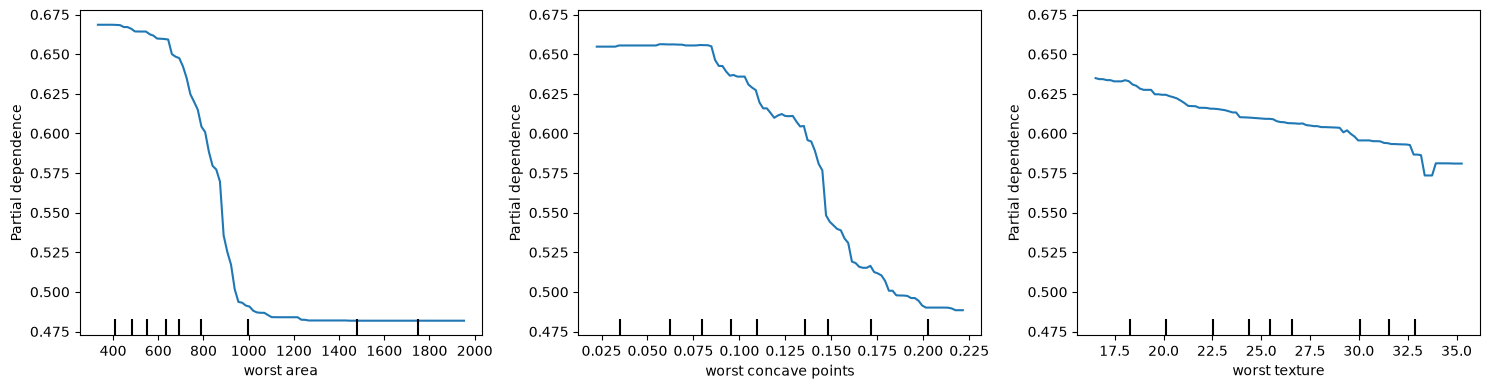

Топ-3 признака: ['worst area', 'worst concave points', 'worst texture']


In [17]:
from sklearn.inspection import PartialDependenceDisplay

top3_names = pi_df.head(3)['feature'].tolist()
top3_idx = [list(feature_names).index(f) for f in top3_names]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, top3_idx, kind='average', ax=ax
)
plt.tight_layout()
plt.show()
print(f'Топ-3 признака: {top3_names}')

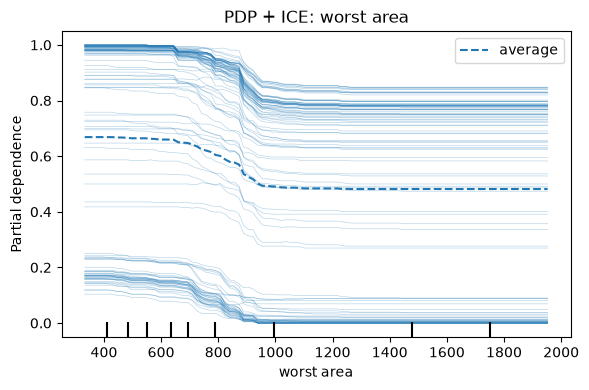

In [18]:
top1_idx = list(feature_names).index(pi_df.iloc[0]['feature'])

fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_idx], kind='both', ax=ax
)
plt.title(f'PDP + ICE: {feature_names[top1_idx]}')
plt.tight_layout()
plt.show()

# Эффект неоднороден: ICE-кривые расходятся — влияние признака зависит от объекта.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [19]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
shap_class1 = shap_values[:, :, 1] if isinstance(shap_values, np.ndarray) else shap_values[1]
print(f'Форма shap_values: {np.array(shap_values).shape}')

Форма shap_values: (114, 30, 2)


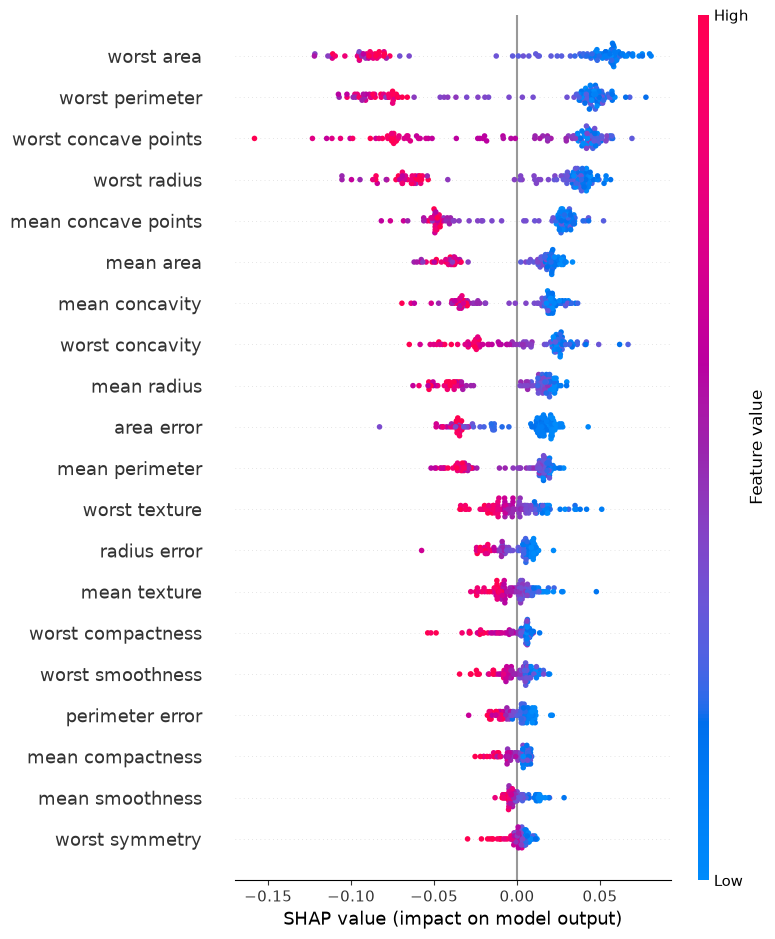

In [20]:
shap.summary_plot(shap_class1, X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


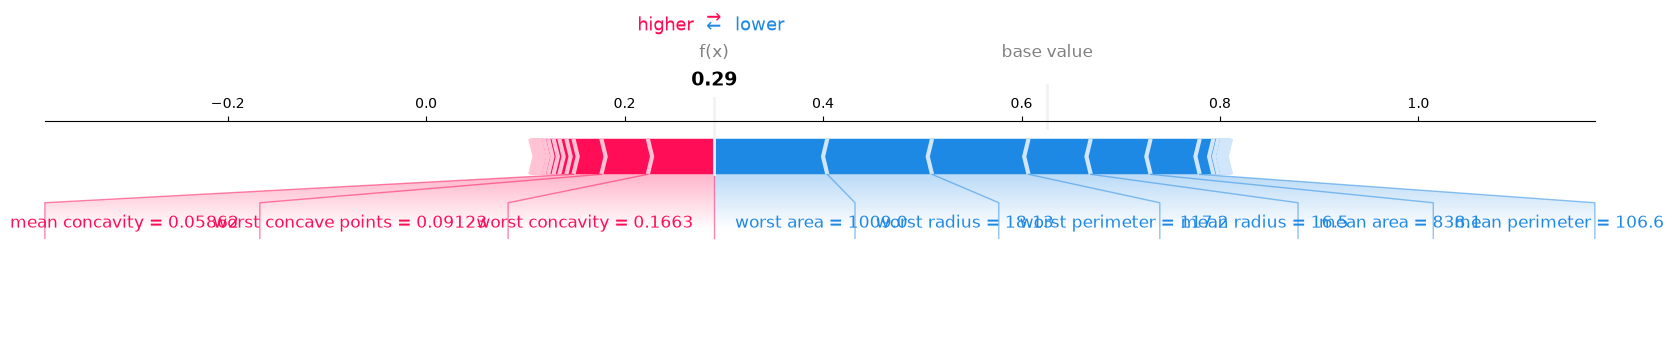

In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

err_idx = errors[0]
ev = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
shap.force_plot(ev, shap_class1[err_idx], X_test.iloc[err_idx], matplotlib=True, show=False)
plt.show()

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [22]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Test F1 с утечкой: 1.0000

Топ PI:
                 feature  importance
30         leaky_feature    0.263342
7    mean concave points    0.004689
27  worst concave points    0.003752
0            mean radius    0.000000
3              mean area    0.000000


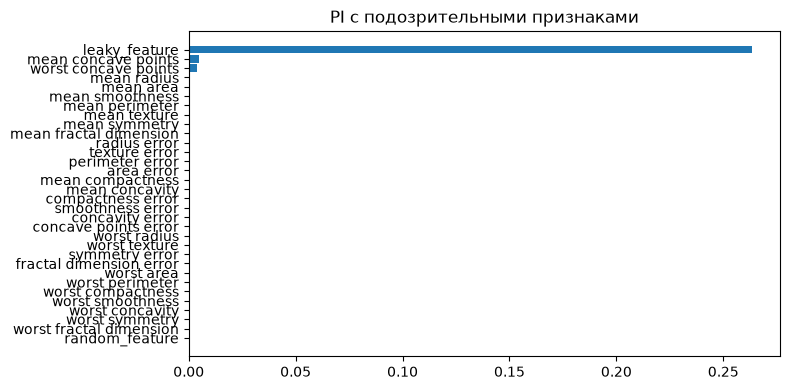

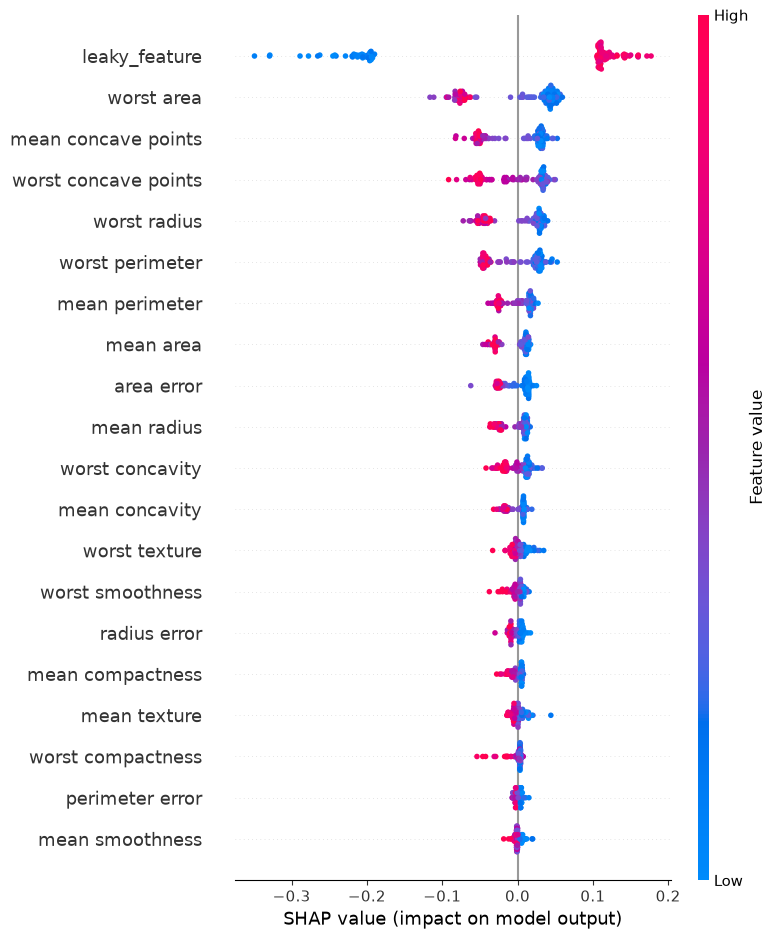

In [23]:
rf_leaky = RandomForestClassifier(random_state=42)
rf_leaky.fit(X_train_ext, y_train)

pi_leaky = permutation_importance(
    rf_leaky, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro'
)
pi_leaky_df = pd.DataFrame({
    'feature': X_train_ext.columns,
    'importance': pi_leaky.importances_mean,
}).sort_values('importance', ascending=False)

explainer_leaky = shap.TreeExplainer(rf_leaky)
shap_leaky = explainer_leaky.shap_values(X_test_ext)

shap_leaky = explainer_leaky.shap_values(X_test_ext)
shap_leaky_c1 = shap_leaky[:, :, 1] if isinstance(shap_leaky, np.ndarray) else shap_leaky[1]

test_f1_leaky = f1_score(y_test, rf_leaky.predict(X_test_ext), average='macro')
print(f'Test F1 с утечкой: {test_f1_leaky:.4f}')
print('\nТоп PI:')
print(pi_leaky_df.head(5))

plt.figure(figsize=(8, 4))
plt.barh(pi_leaky_df['feature'][::-1], pi_leaky_df['importance'][::-1])
plt.title('PI с подозрительными признаками')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_leaky_c1, X_test_ext, show=False)
plt.tight_layout()
plt.show()

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [24]:
svm_base = clone(base_models['SVM']).fit(X_train, y_train)
rf_base = clone(base_models['RandomForest']).fit(X_train, y_train)

final_summary = pd.DataFrame([
    {'Метод': 'SVM baseline', 'CV F1': f"{baseline_results['SVM'][0]:.4f}",
     'Test F1': f"{f1_score(y_test, svm_base.predict(X_test), average='macro'):.4f}",
     'Выводы': 'Базовая точка отсчёта'},
    {'Метод': 'SVM Grid Search', 'CV F1': f"{svm_grid_search.best_score_:.4f}",
     'Test F1': f"{f1_score(y_test, svm_grid_search.predict(X_test), average='macro'):.4f}",
     'Выводы': 'Подбор C/gamma/kernel улучшает SVM'},
    {'Метод': 'RF baseline', 'CV F1': f"{baseline_results['RandomForest'][0]:.4f}",
     'Test F1': f"{f1_score(y_test, rf_base.predict(X_test), average='macro'):.4f}",
     'Выводы': 'Дефолтный RF уже силён'},
    {'Метод': 'RF Rand Search', 'CV F1': f"{rf_random_search.best_score_:.4f}",
     'Test F1': f"{f1_score(y_test, rf_random_search.predict(X_test), average='macro'):.4f}",
     'Выводы': 'Random Search даёт небольшой прирост'},
])
display(final_summary)

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.9694,0.9812,Базовая точка отсчёта
1,SVM Grid Search,0.9786,0.9812,Подбор C/gamma/kernel улучшает SVM
2,RF baseline,0.9504,0.9526,Дефолтный RF уже силён
3,RF Rand Search,0.9554,0.9526,Random Search даёт небольшой прирост


### Итоги

1. **Тюнинг** даёт умеренный прирост F1 (особенно для SVM); RF с дефолтными параметрами уже близок к оптимуму.
2. **PI и SHAP** в целом согласны по топ-признакам; расхождения возможны из-за корреляций между признаками.
3. **Без Pipeline** масштабирование пришлось бы применять отдельно — риск data leakage при CV.
4. **В проекте**: PI — быстрый скрининг важности; SHAP — объяснение конкретных предсказаний и поиск утечек.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

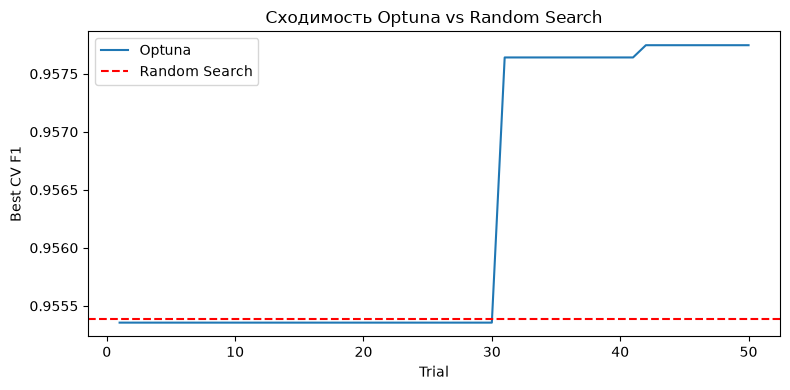

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 188, 'max_depth': 11, 'min_samples_split': 4, 'max_features': 0.5}


In [25]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    }
    model = RandomForestClassifier(random_state=42, **params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_values = [t.value for t in study.trials if t.value is not None]
best_over_time = np.maximum.accumulate(best_values)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_over_time) + 1), best_over_time, label='Optuna')
plt.axhline(rf_random_search.best_score_, color='r', ls='--', label='Random Search')
plt.xlabel('Trial')
plt.ylabel('Best CV F1')
plt.legend()
plt.title('Сходимость Optuna vs Random Search')
plt.tight_layout()
plt.show()

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")